In [ ]:
from tapas_gmm.dataset.scene import SceneDataset
from pathlib import Path
from tapas_gmm.dataset.bc import BCDataset, BCDataConfig
from torch.utils.data import DataLoader
from tapas_gmm.utils.observation import collate
from tapas_gmm.dataset.demos import Demos

from tapas_gmm.policy.models.tpgmm import (
    AutoTPGMM,
    AutoTPGMMConfig,
    TPGMMConfig,
    DemoSegmentationConfig,
    FittingStage,
)

2026-06-13 09:13:16.534 | INFO     |  Running on cpu


/home/nils/Documents/Study Project/Code/riepybdlib/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
data_root = Path("../outputs/bimanual_dataset")

In [3]:
loaded_dataset = SceneDataset(
    data_root=Path(data_root)
)

2026-06-13 09:13:27.583 | INFO     |  Initializing datasete using ../outputs/bimanual_dataset/metadata.json
2026-06-13 09:13:27.706 | INFO     |  Extracted gt object labels []
2026-06-13 09:13:27.706 | INFO     |  Extracted tsdf object labels []


In [ ]:
bc_config = BCDataConfig(
    fragment_length = -1,
    cameras = tuple(),
)

bc_dataset = BCDataset(
    scene_dataset=loaded_dataset,
    config=bc_config,
)

2026-06-13 09:13:27.717 | INFO     |  Initializing BCDataset:
2026-06-13 09:13:27.717 | INFO     |    Training on fragments of length -1.
2026-06-13 09:13:27.717 | INFO     |    Loading raw data for encoder.


In [5]:
loader = DataLoader(
    bc_dataset,
    collate_fn=collate,
)

In [6]:
def make_arm_traj(traj, arm):
    arm_traj = traj.clone()

    if arm == "left":
        arm_traj.ee_pose = traj.ee_pose[:, :7]
        arm_traj.gripper_state = traj.gripper_state[:, :1]
        arm_traj.action = traj.action[:, :7]

    elif arm == "right":
        arm_traj.ee_pose = traj.ee_pose[:, 7:]
        arm_traj.gripper_state = traj.gripper_state[:, 1:]
        arm_traj.action = traj.action[:, 7:]

    return arm_traj

In [ ]:
left_trajs = []
right_trajs = []

for batch in loader:
    sample = batch[0]

    left_traj = make_arm_traj(sample, "left")
    right_traj = make_arm_traj(sample, "right")

    left_trajs.append(left_traj)
    right_trajs.append(right_traj)

left_demos = Demos(trajectories = left_trajs)
right_demos = Demos(trajectories = right_trajs)

2026-06-13 09:13:31.363 | INFO     |  Subsampling to length 104 using strategy mean-length.


In [ ]:
print(type(left_traj[0].ee_pose))
print(left_traj[0].ee_pose)



<class 'torch.Tensor'>
7


In [ ]:
tpgmm_config = TPGMMConfig(
    add_time_component = True,
)

segmentation_config = DemoSegmentationConfig(
    distance_based = False,
    velocity_based = True,
)

auto_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    demos_segmentation=segmentation_config,
)


2026-06-13 09:16:06.673 | INFO     |  Fitting AutoTPGMM
2026-06-13 09:16:06.673 | INFO     |  Segmenting trajectories


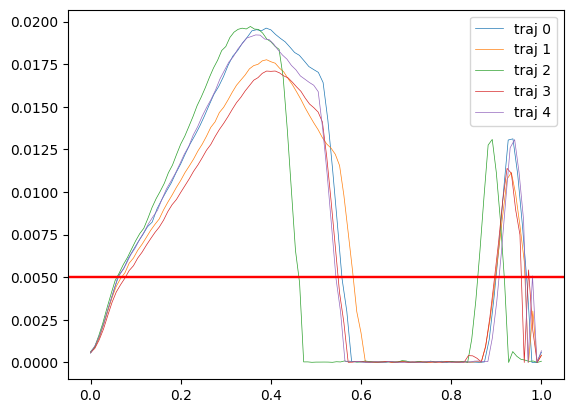

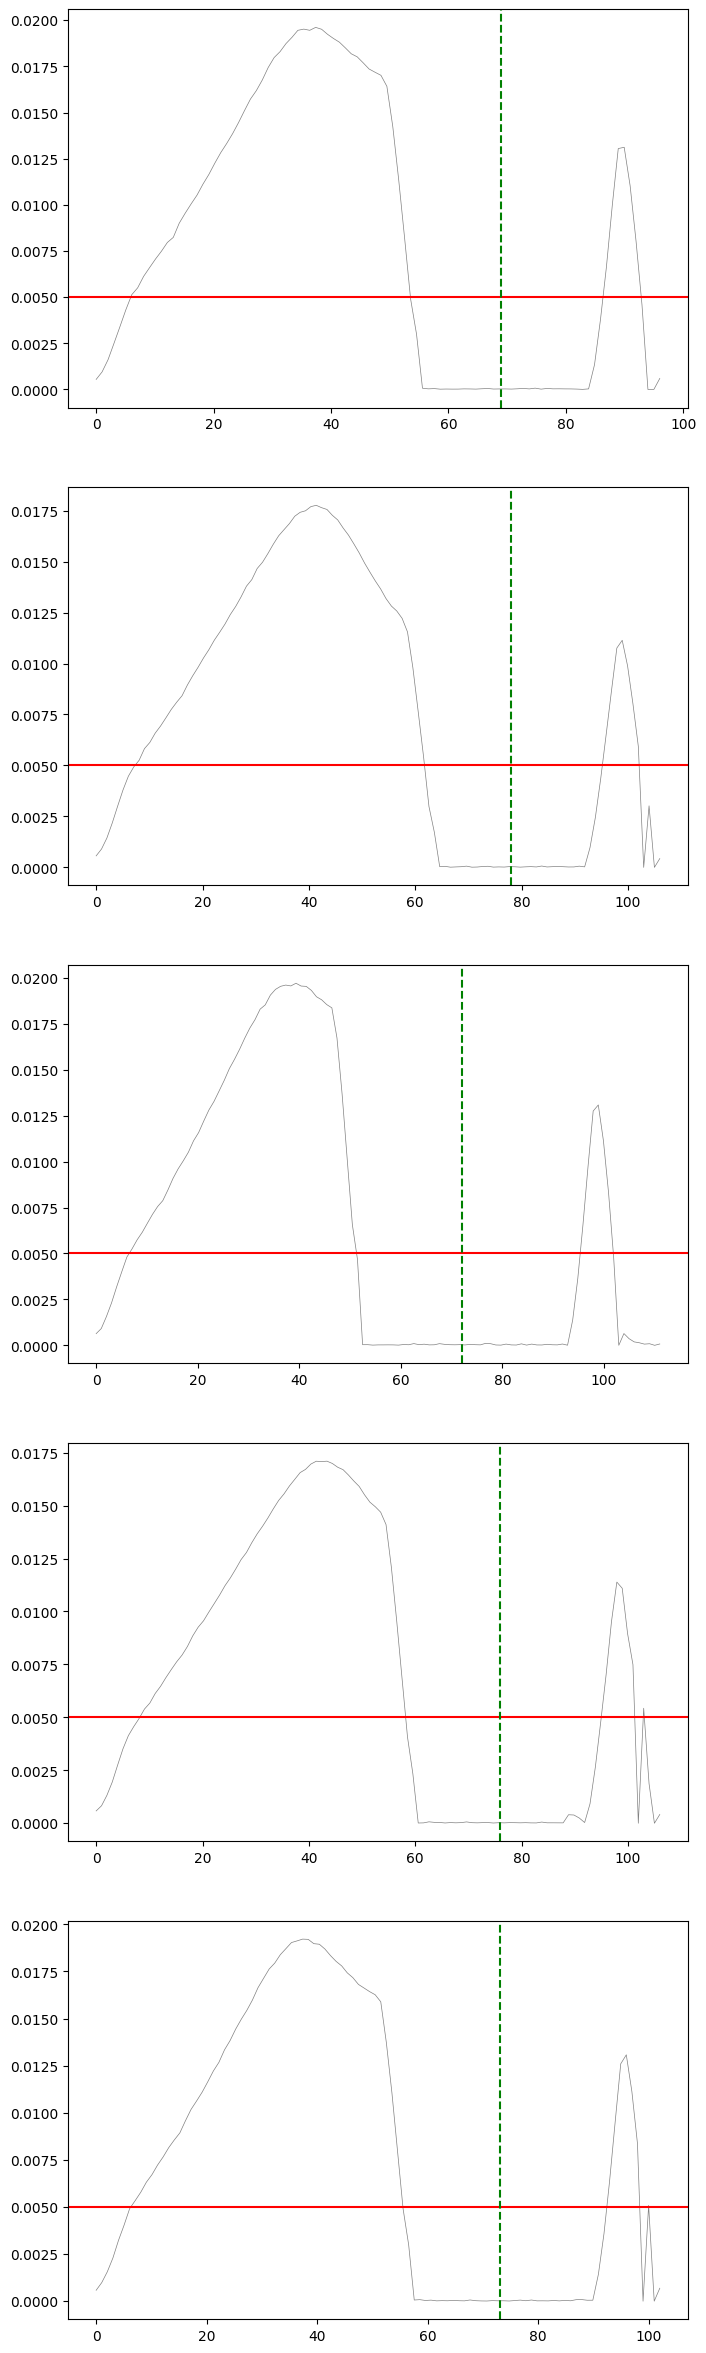

2026-06-13 09:16:07.635 | INFO     |  Creating segement of demos.
2026-06-13 09:16:07.640 | INFO     |  Subsampling to length 82 using strategy mean-length.
2026-06-13 09:16:07.641 | INFO     |  Creating segement of demos.
2026-06-13 09:16:07.646 | INFO     |  Subsampling to length 39 using strategy mean-length.
2026-06-13 09:16:07.646 | INFO     |  ... created 2 segments
2026-06-13 09:16:07.646 | INFO     |    Fitting candidate frame 1/5
2026-06-13 09:16:07.647 | INFO     |    Creating partial frame view of demos.
2026-06-13 09:16:07.652 | INFO     |    Manifold: TIME x R3 x QUAT
2026-06-13 09:16:07.652 | INFO     |    Changing number of components to 2
2026-06-13 09:16:07.652 | INFO     |    Init strategy not specified. Auto selected InitStrategy.TIME_BASED.
2026-06-13 09:16:07.653 | INFO     |    Model init ...


Time-based init:   0%|          | 0/2 [00:00<?, ?it/s]

2026-06-13 09:16:07.794 | INFO     |    HMM EM ...
2026-06-13 09:16:07.795 | INFO     |    HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-06-13 09:16:07.812 | INFO     |    HMM init priors not defined, initializing to uniform
2026-06-13 09:16:08.197 | INFO     |    HMM EM converged
2026-06-13 09:16:08.200 | INFO     |    Fitting candidate frame 2/5
2026-06-13 09:16:08.200 | INFO     |    Creating partial frame view of demos.


...

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-06-13 09:16:33.939 | INFO     |  Changing number of components to 3


Time-based init:   0%|          | 0/3 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

(5879.1795238223585, 2973.0015728135318)


In [ ]:
left_model = AutoTPGMM(auto_config)

left_lik, left_avg_loglik = left_model.fit_trajectories(
    demos = left_demos,
    fitting_actions = [ 
        FittingStage.INIT,
        FittingStage.EM_HMM,
    ],
)

print(left_avg_loglik)

2026-06-13 10:39:30.891 | INFO     |  Did not specify time_based, deciding automatically.


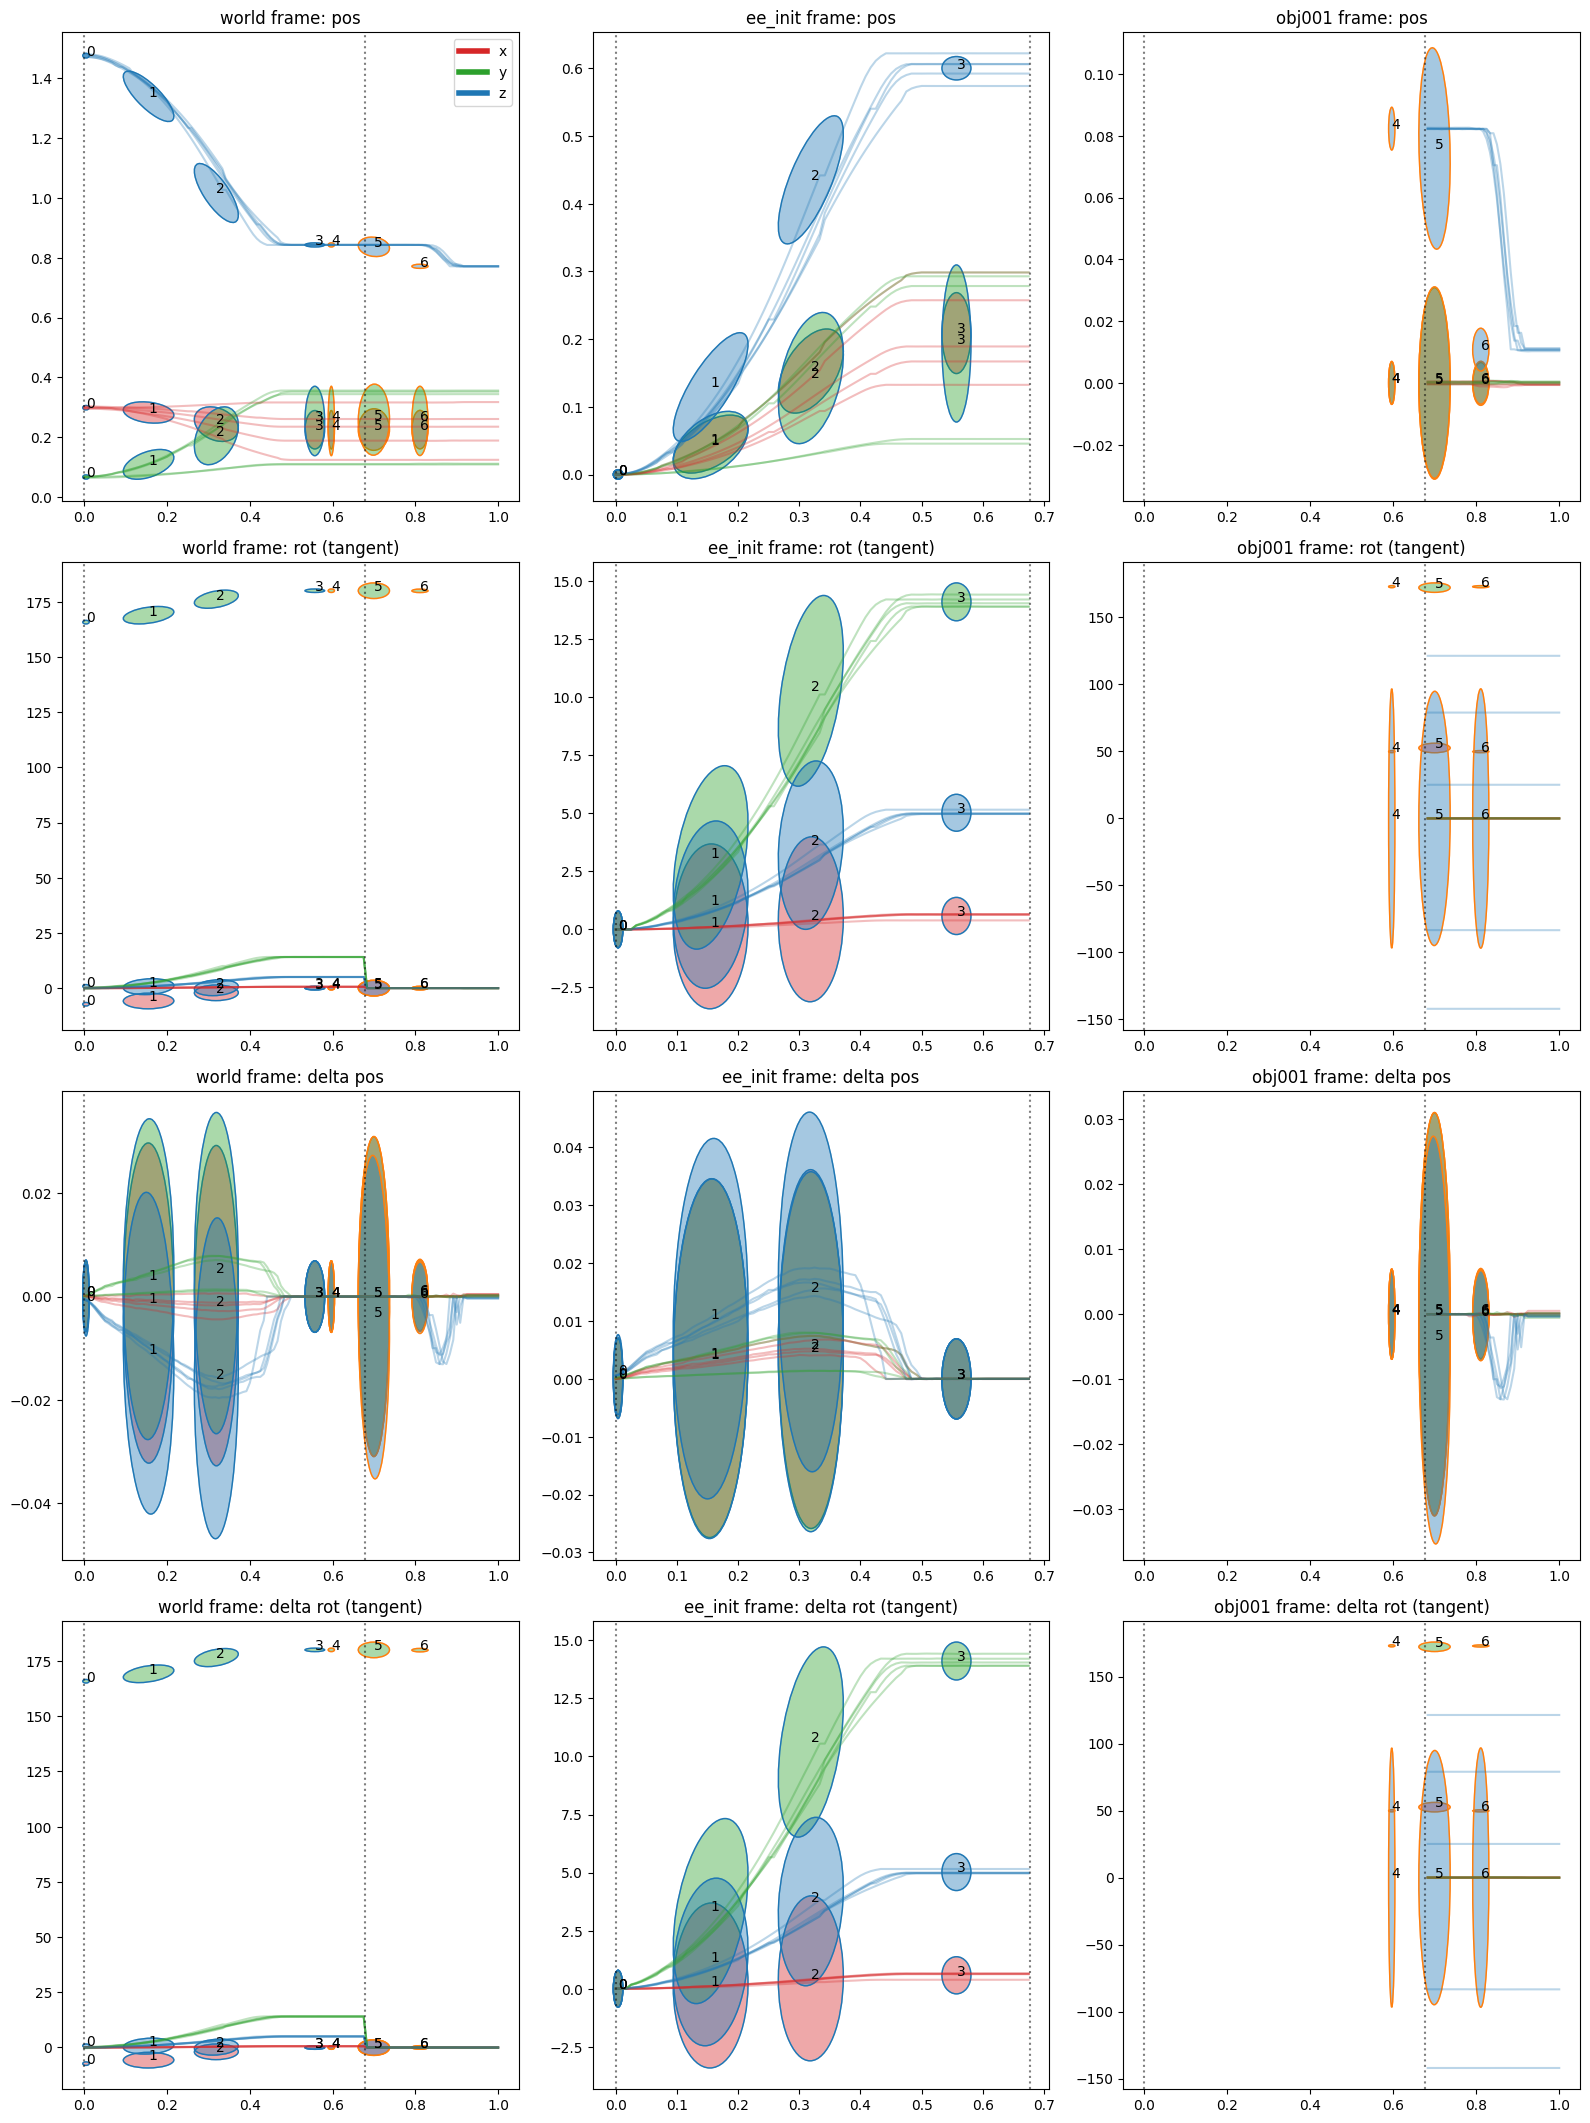

In [18]:
left_model.plot_model(
    rotations_raw=False)